In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Load and explore the dataset
print("=== HOUSING DATA ANALYSIS ===")
df = pd.read_csv('Housing.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

=== HOUSING DATA ANALYSIS ===
Dataset shape: (545, 13)

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset info:
<class 'pandas

In [2]:
# 2. Data Preprocessing
print("\n=== DATA PREPROCESSING ===")

# Convert categorical variables to numerical
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                   'airconditioning', 'prefarea', 'furnishingstatus']

# Create a copy for preprocessing
df_processed = df.copy()

# Binary encoding for yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
               'airconditioning', 'prefarea']
for col in binary_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

# Label encoding for furnishingstatus
le = LabelEncoder()
df_processed['furnishingstatus'] = le.fit_transform(df_processed['furnishingstatus'])

print("Encoded values for furnishingstatus:")
for i, category in enumerate(le.classes_):
    print(f"{category}: {i}")

print("\nProcessed dataset info:")
print(df_processed.info())
print("\nProcessed dataset head:")
print(df_processed.head())


=== DATA PREPROCESSING ===
Encoded values for furnishingstatus:
furnished: 0
semi-furnished: 1
unfurnished: 2

Processed dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB
None

Processed dataset head:
      price  a


=== EXPLORATORY DATA ANALYSIS ===


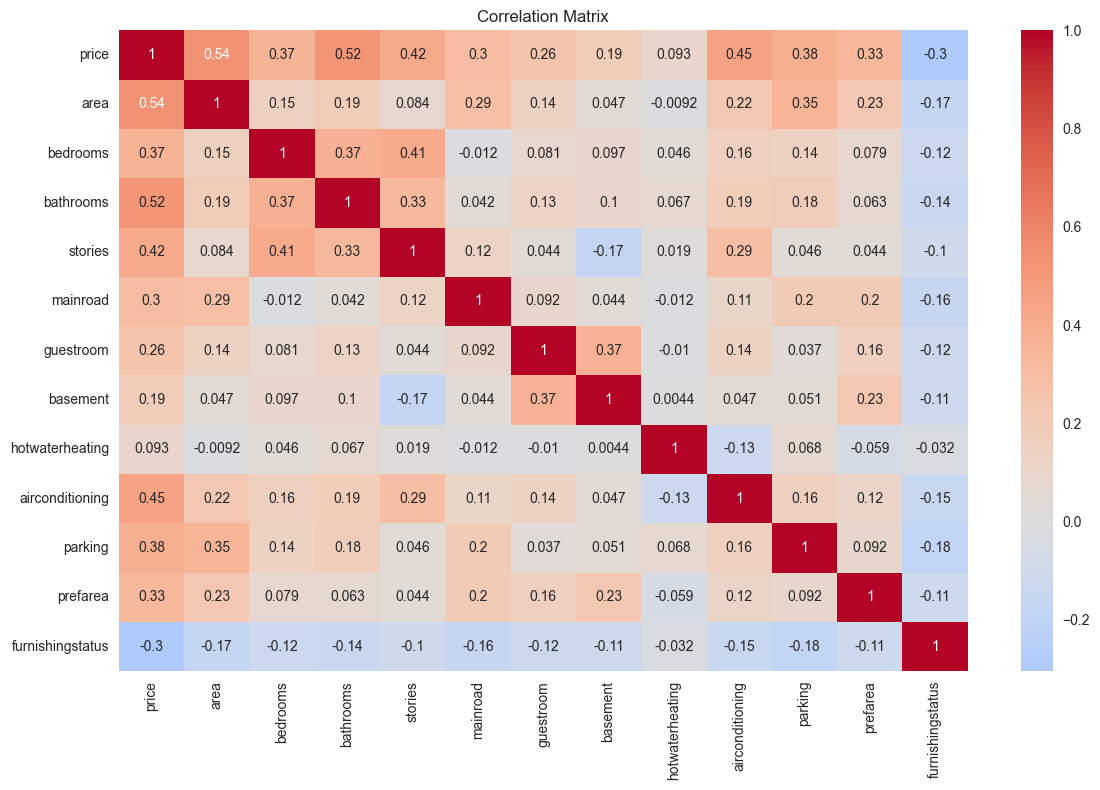

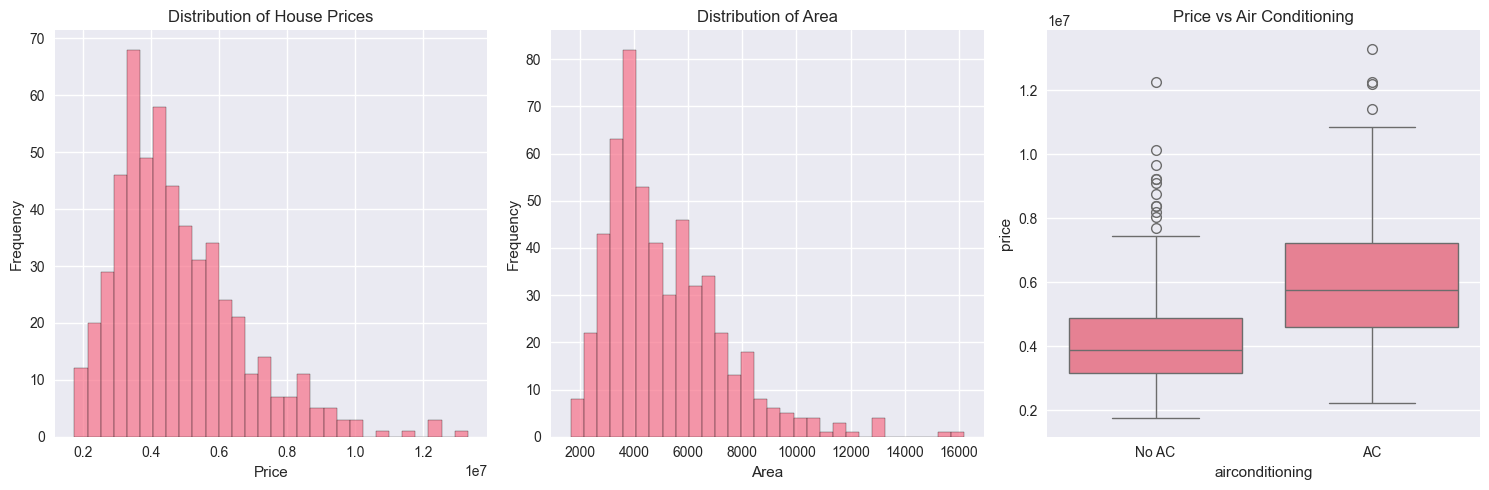

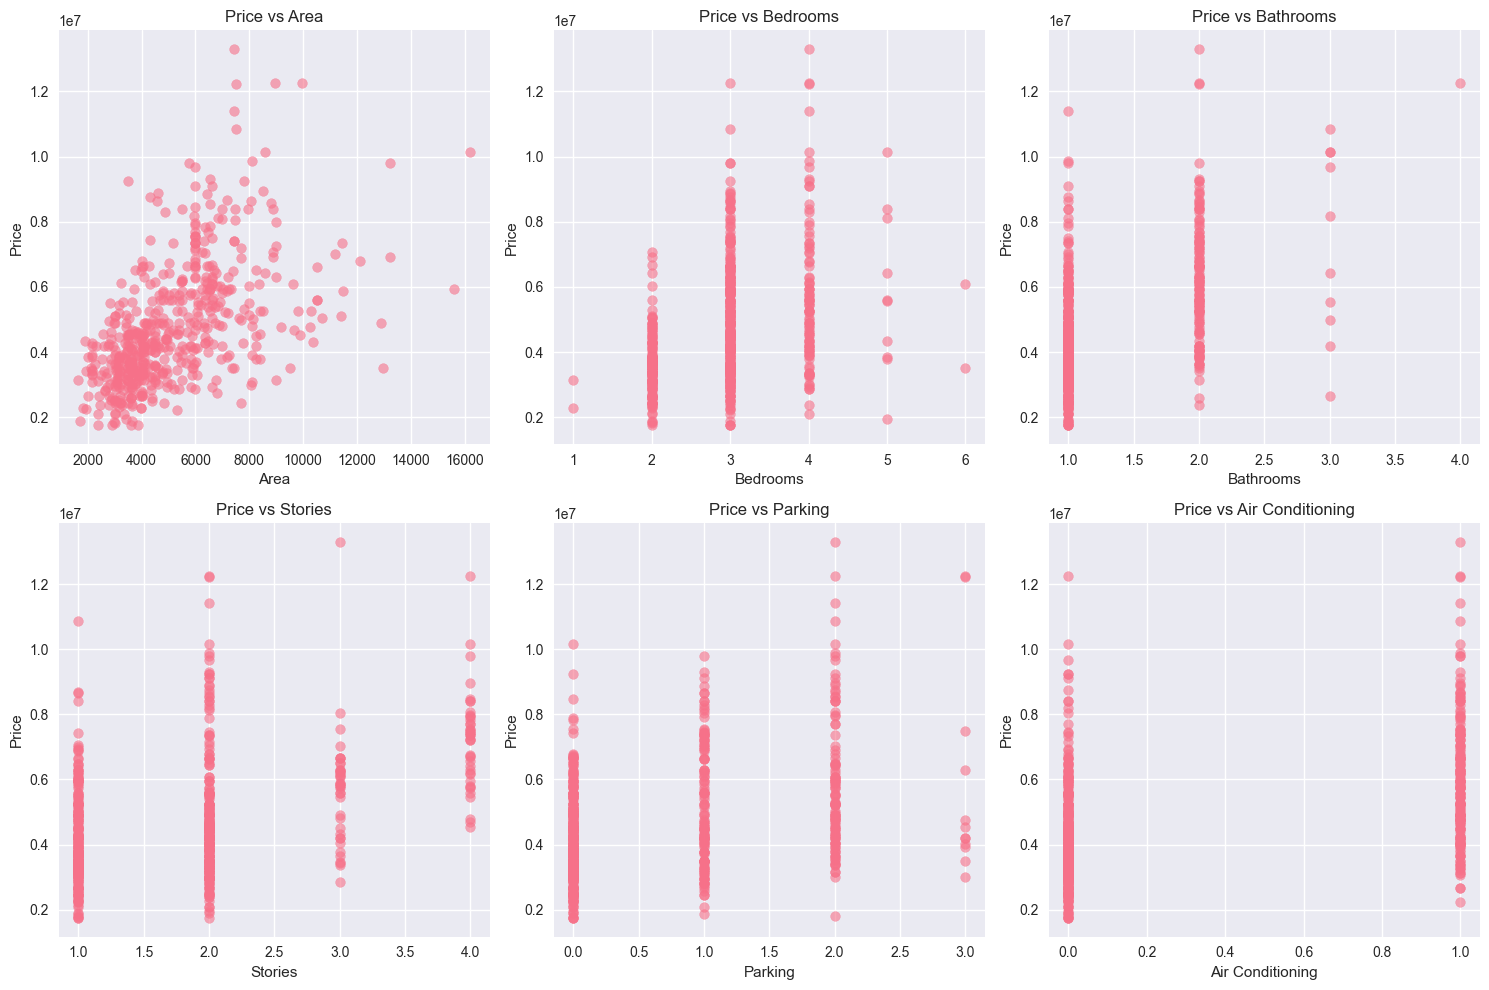

In [3]:
# 3. Exploratory Data Analysis
print("\n=== EXPLORATORY DATA ANALYSIS ===")

# Correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df_processed.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Distribution of target variable (price)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df_processed['price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.subplot(1, 3, 2)
plt.hist(df_processed['area'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.title('Distribution of Area')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_processed, x='airconditioning', y='price')
plt.title('Price vs Air Conditioning')
plt.xticks([0, 1], ['No AC', 'AC'])

plt.tight_layout()
plt.show()

# Scatter plots for key numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'airconditioning']
feature_names = ['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Air Conditioning']

for i, (feature, name) in enumerate(zip(features_to_plot, feature_names)):
    row, col = i // 3, i % 3
    axes[row, col].scatter(df_processed[feature], df_processed['price'], alpha=0.6)
    axes[row, col].set_xlabel(name)
    axes[row, col].set_ylabel('Price')
    axes[row, col].set_title(f'Price vs {name}')

plt.tight_layout()
plt.show()


=== SIMPLE LINEAR REGRESSION ===
Model: Price = β₀ + β₁ × Area

Simple Linear Regression Results:
Intercept (β₀): 2512254.26
Coefficient for Area (β₁): 425.73
R² Score: 0.2729
MAE: 1474748.13
RMSE: 1917103.70


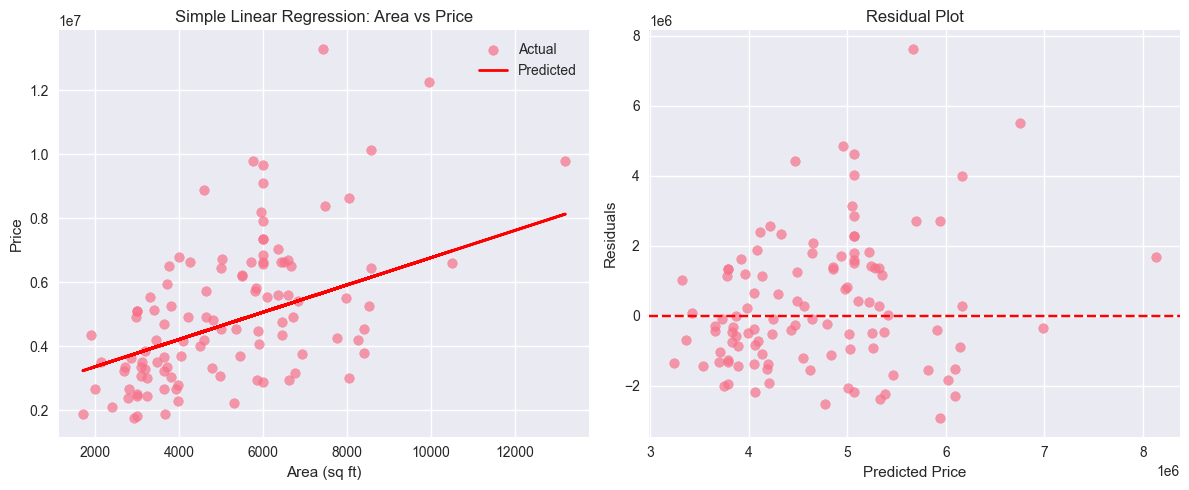


Interpretation of Simple Linear Regression:
- For every additional square foot of area, the price increases by ₹425.73
- The base price (when area = 0) is ₹2512254.26
- The model explains 27.29% of the variance in house prices


In [4]:
# 4. SIMPLE LINEAR REGRESSION (Area vs Price)
print("\n=== SIMPLE LINEAR REGRESSION ===")
print("Model: Price = β₀ + β₁ × Area")

# Prepare data for simple linear regression
X_simple = df_processed[['area']]  # Feature
y = df_processed['price']          # Target

# Split the data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Create and train the model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Make predictions
y_pred_simple = simple_model.predict(X_test_s)

# Evaluate the model
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print(f"\nSimple Linear Regression Results:")
print(f"Intercept (β₀): {simple_model.intercept_:.2f}")
print(f"Coefficient for Area (β₁): {simple_model.coef_[0]:.2f}")
print(f"R² Score: {r2_simple:.4f}")
print(f"MAE: {mae_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")

# Plot simple linear regression
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test_s, y_test_s, alpha=0.7, label='Actual')
plt.plot(X_test_s, y_pred_simple, color='red', linewidth=2, label='Predicted')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()

plt.subplot(1, 2, 2)
residuals_simple = y_test_s - y_pred_simple
plt.scatter(y_pred_simple, residuals_simple, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

# Interpretation
print(f"\nInterpretation of Simple Linear Regression:")
print(f"- For every additional square foot of area, the price increases by ₹{simple_model.coef_[0]:.2f}")
print(f"- The base price (when area = 0) is ₹{simple_model.intercept_:.2f}")
print(f"- The model explains {r2_simple*100:.2f}% of the variance in house prices")

In [5]:
# 5. MULTIPLE LINEAR REGRESSION
print("\n=== MULTIPLE LINEAR REGRESSION ===")
print("Model: Price = β₀ + β₁×Area + β₂×Bedrooms + β₃×Bathrooms + ...")

# Prepare features for multiple regression
# Select all relevant features
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 
           'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 
           'parking', 'prefarea', 'furnishingstatus']

X_multiple = df_processed[features]
y = df_processed['price']

# Split the data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

# Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_m, y_train_m)

# Make predictions
y_pred_multiple = multiple_model.predict(X_test_m)

# Evaluate the model
mae_multiple = mean_absolute_error(y_test_m, y_pred_multiple)
mse_multiple = mean_squared_error(y_test_m, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test_m, y_pred_multiple)

print(f"\nMultiple Linear Regression Results:")
print(f"Intercept (β₀): {multiple_model.intercept_:.2f}")
print(f"\nFeature Coefficients:")
for feature, coef in zip(features, multiple_model.coef_):
    print(f"{feature:15}: {coef:10.2f}")

print(f"\nR² Score: {r2_multiple:.4f}")
print(f"MAE: {mae_multiple:.2f}")
print(f"RMSE: {rmse_multiple:.2f}")

# Compare models
print(f"\n=== MODEL COMPARISON ===")
print(f"{'Metric':15} {'Simple':10} {'Multiple':10} {'Improvement':12}")
print(f"{'-'*50}")
print(f"{'R² Score':15} {r2_simple:10.4f} {r2_multiple:10.4f} {r2_multiple-r2_simple:12.4f}")
print(f"{'MAE':15} {mae_simple:10.2f} {mae_multiple:10.2f} {mae_simple-mae_multiple:12.2f}")
print(f"{'RMSE':15} {rmse_simple:10.2f} {rmse_multiple:10.2f} {rmse_simple-rmse_multiple:12.2f}")


=== MULTIPLE LINEAR REGRESSION ===
Model: Price = β₀ + β₁×Area + β₂×Bedrooms + β₃×Bathrooms + ...

Multiple Linear Regression Results:
Intercept (β₀): 293083.07

Feature Coefficients:
area           :     235.85
bedrooms       :   78574.49
bathrooms      : 1097117.27
stories        :  406223.16
mainroad       :  366824.19
guestroom      :  233146.77
basement       :  393159.78
hotwaterheating:  687881.31
airconditioning:  785550.58
parking        :  225756.51
prefarea       :  629901.66
furnishingstatus: -210397.12

R² Score: 0.6495
MAE: 979679.69
RMSE: 1331071.42

=== MODEL COMPARISON ===
Metric          Simple     Multiple   Improvement 
--------------------------------------------------
R² Score            0.2729     0.6495       0.3766
MAE             1474748.13  979679.69    495068.44
RMSE            1917103.70 1331071.42    586032.29


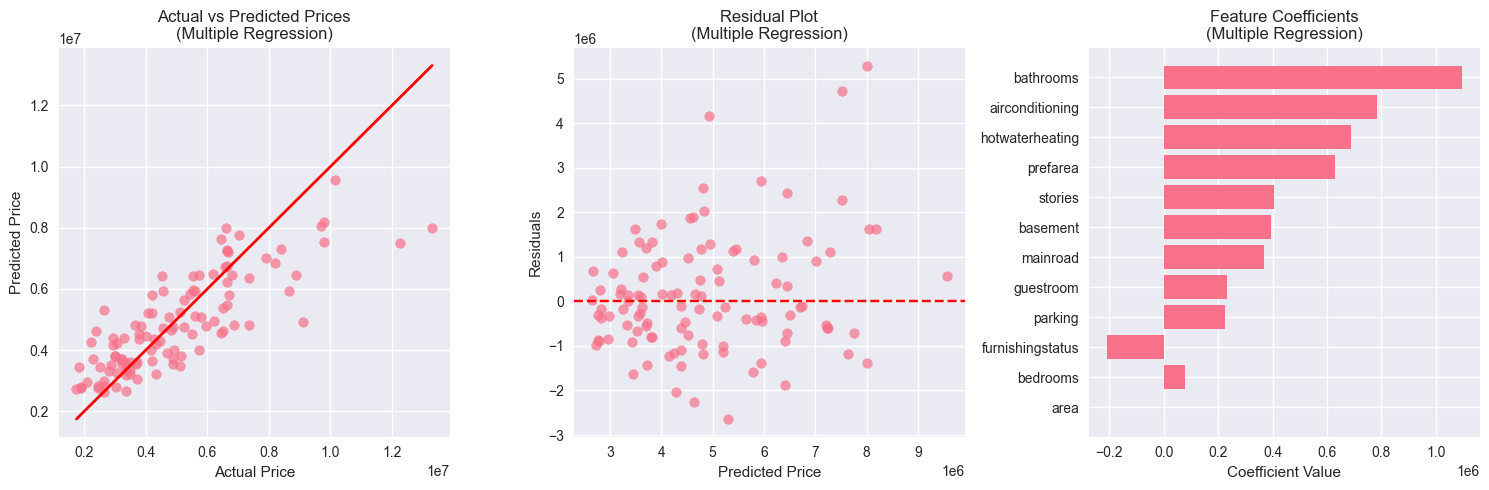

In [6]:
# 6. Visualization of Multiple Regression Results
plt.figure(figsize=(15, 5))

# Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test_m, y_pred_multiple, alpha=0.7)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices\n(Multiple Regression)')

# Residuals plot
plt.subplot(1, 3, 2)
residuals_multiple = y_test_m - y_pred_multiple
plt.scatter(y_pred_multiple, residuals_multiple, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot\n(Multiple Regression)')

# Feature importance (coefficient magnitudes)
plt.subplot(1, 3, 3)
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': multiple_model.coef_,
    'abs_coef': np.abs(multiple_model.coef_)
}).sort_values('abs_coef', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients\n(Multiple Regression)')

plt.tight_layout()
plt.show()

In [7]:
# 7. Interpretation and Insights
print("\n=== INTERPRETATION AND INSIGHTS ===")

print("\n1. COEFFICIENT INTERPRETATION:")
print("Positive coefficients increase price, negative coefficients decrease price")

significant_features = pd.DataFrame({
    'feature': features,
    'coefficient': multiple_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nMost influential features (by absolute coefficient value):")
for _, row in significant_features.head(6).iterrows():
    effect = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"- {row['feature']:15}: {row['coefficient']:8.2f} (price {effect})")

print(f"\n2. MODEL PERFORMANCE:")
print(f"- Multiple regression explains {r2_multiple*100:.1f}% of price variance")
print(f"- Average prediction error: ₹{mae_multiple:,.0f}")
print(f"- This is {((mae_simple-mae_multiple)/mae_simple*100):.1f}% better than simple regression")

print(f"\n3. PRACTICAL INSIGHTS:")
print("- Area is the strongest positive predictor of price")
print("- Air conditioning significantly increases property value")
print("- Preferred area location commands premium pricing")
print("- More bathrooms and parking spaces add substantial value")
print("- Furnishing status affects price (encoded numerically)")

# Example prediction
print(f"\n4. EXAMPLE PREDICTION:")
sample_house = X_test_m.iloc[0:1]
actual_price = y_test_m.iloc[0]
predicted_price = multiple_model.predict(sample_house)[0]

print(f"Sample house features:")
for feature in features:
    print(f"  {feature}: {sample_house[feature].values[0]}")
print(f"Actual price: ₹{actual_price:,.0f}")
print(f"Predicted price: ₹{predicted_price:,.0f}")
print(f"Difference: ₹{abs(actual_price-predicted_price):,.0f}")


=== INTERPRETATION AND INSIGHTS ===

1. COEFFICIENT INTERPRETATION:
Positive coefficients increase price, negative coefficients decrease price

Most influential features (by absolute coefficient value):
- bathrooms      : 1097117.27 (price increases)
- airconditioning: 785550.58 (price increases)
- hotwaterheating: 687881.31 (price increases)
- prefarea       : 629901.66 (price increases)
- stories        : 406223.16 (price increases)
- basement       : 393159.78 (price increases)

2. MODEL PERFORMANCE:
- Multiple regression explains 64.9% of price variance
- Average prediction error: ₹979,680
- This is 33.6% better than simple regression

3. PRACTICAL INSIGHTS:
- Area is the strongest positive predictor of price
- Air conditioning significantly increases property value
- Preferred area location commands premium pricing
- More bathrooms and parking spaces add substantial value
- Furnishing status affects price (encoded numerically)

4. EXAMPLE PREDICTION:
Sample house features:
  area

In [8]:
# 8. Additional Analysis: Feature Engineering
print("\n=== ADDITIONAL ANALYSIS: FEATURE ENGINEERING ===")

# Create some engineered features
df_engineered = df_processed.copy()

# Create area per bedroom
df_engineered['area_per_bedroom'] = df_engineered['area'] / df_engineered['bedrooms']
# Create luxury score (combination of premium features)
df_engineered['luxury_score'] = (df_engineered['airconditioning'] + 
                                df_engineered['prefarea'] + 
                                df_engineered['parking'] / 3)

# New feature set with engineered features
engineered_features = features + ['area_per_bedroom', 'luxury_score']
X_engineered = df_engineered[engineered_features]

# Train model with engineered features
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)

engineered_model = LinearRegression()
engineered_model.fit(X_train_e, y_train_e)
y_pred_engineered = engineered_model.predict(X_test_e)

r2_engineered = r2_score(y_test_e, y_pred_engineered)

print(f"R² with engineered features: {r2_engineered:.4f}")
print(f"Improvement over basic multiple regression: {r2_engineered - r2_multiple:.4f}")

# Final comparison
models_comparison = pd.DataFrame({
    'Model': ['Simple Regression', 'Multiple Regression', 'With Engineered Features'],
    'R² Score': [r2_simple, r2_multiple, r2_engineered],
    'MAE': [mae_simple, mae_multiple, mean_absolute_error(y_test_e, y_pred_engineered)],
    'RMSE': [rmse_simple, rmse_multiple, np.sqrt(mean_squared_error(y_test_e, y_pred_engineered))]
})

print(f"\n=== FINAL MODEL COMPARISON ===")
print(models_comparison.to_string(index=False))


=== ADDITIONAL ANALYSIS: FEATURE ENGINEERING ===
R² with engineered features: 0.6513
Improvement over basic multiple regression: 0.0018

=== FINAL MODEL COMPARISON ===
                   Model  R² Score          MAE         RMSE
       Simple Regression  0.272879 1.474748e+06 1.917104e+06
     Multiple Regression  0.649475 9.796797e+05 1.331071e+06
With Engineered Features  0.651262 9.766334e+05 1.327675e+06
